<a href="https://colab.research.google.com/github/HitanshuGedam/quantum-learning-journey/blob/main/Day1_Hilbert_Spaces_Dirac_Notation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qutip pennylane numpy scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.8 MB/s eta 0:00:00


# Day 1: Complex Vector Spaces, Hilbert Spaces, and Dirac Notation

## Overview

This notebook establishes the mathematical foundation for quantum mechanics and quantum computing. The three core ideas covered are:

1. **Complex vector spaces** – why complex numbers are essential for quantum theory
2. **Hilbert spaces** – vector spaces equipped with an inner product and completeness
3. **Dirac notation (bra-ket)** – the standard language for describing quantum states

**Visualizations:** We will use the Bloch sphere to represent qubit states geometrically.

By the end of this notebook, we will have implemented basic vector operations, verified orthonormality, constructed superposition states, and explored the geometric meaning of inner products.

## References

- Nielsen, M. A., & Chuang, I. L. (2010). *Quantum Computation and Quantum Information: 10th Anniversary Edition*. Cambridge University Press. Chapters 1–2.
- [3Blue1Brown Linear Algebra Playlist](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)

In [9]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# Display options
np.set_printoptions(precision=4, suppress=False)

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. Complex Vector Spaces

A **vector space** over the complex numbers $\mathbb{C}$ is a set of vectors closed under addition and scalar multiplication by complex numbers.

For a qubit, the state space is $\mathbb{C}^2$ – all column vectors of the form:

$$
|\psi\rangle = \begin{pmatrix} \alpha \\ \beta \end{pmatrix}, \quad \alpha, \beta \in \mathbb{C}
$$

**Why complex numbers?** Real numbers alone cannot capture interference phenomena. The relative phase between $\alpha$ and $\beta$ produces observable effects (e.g., in the double-slit experiment or the Mach–Zehnder interferometer), which would be impossible with real amplitudes alone.

### Computational Basis

The standard orthonormal basis for $\mathbb{C}^2$ is:

$$
|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad
|1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}
$$

Any state can be written as $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ with $|\alpha|^2 + |\beta|^2 = 1$.

|0⟩ = [1.+0.j 0.+0.j]
|1⟩ = [0.+0.j 1.+0.j]


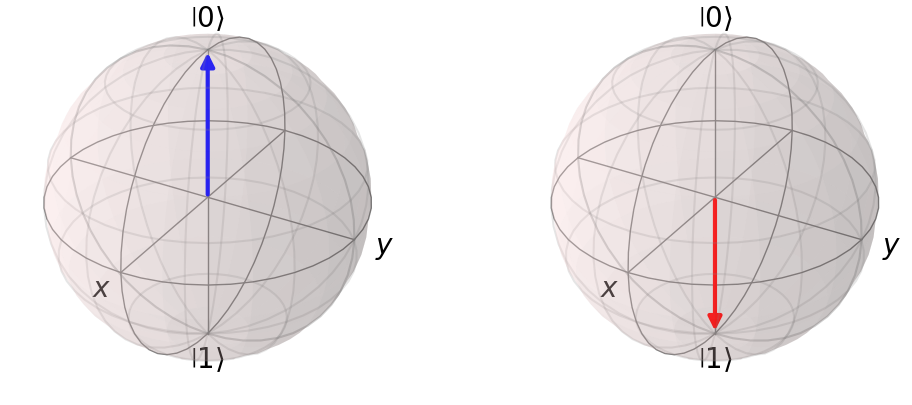

In [14]:
# Computational basis states
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

print("|0⟩ =", ket0)
print("|1⟩ =", ket1)

# Visualize |0⟩ and |1⟩ on the Bloch sphere - FIXED VERSION
fig = plt.figure(figsize=(12, 5))

# Left plot: |0⟩
ax1 = fig.add_subplot(121, projection='3d')
bloch0 = qt.Bloch(fig=fig, axes=ax1)
bloch0.add_states(qt.ket2dm(qt.basis(2, 0)))
bloch0.vector_color = ['blue']
bloch0.title = r"$|0\rangle$ (North Pole)"
bloch0.render()

# Right plot: |1⟩
ax2 = fig.add_subplot(122, projection='3d')
bloch1 = qt.Bloch(fig=fig, axes=ax2)
bloch1.add_states(qt.ket2dm(qt.basis(2, 1)))
bloch1.vector_color = ['red']
bloch1.title = r"$|1\rangle$ (South Pole)"
bloch1.render()


## 2. Dirac Notation (Bra-Ket)

### Definitions

Let |ψ⟩ and |φ⟩ be two quantum states in C^2:

|ψ⟩ = (α, β)^T,    |φ⟩ = (γ, δ)^T

where α, β, γ, δ ∈ C (complex numbers).

| Symbol        | Name | Meaning                                 |
|:--------------|:-----|:----------------------------------------|
| `|ψ⟩`         | Ket  | Column vector                           |
| `⟨ψ|`         | Bra  | Row vector, conjugate transpose of ket  |
| `⟨φ|ψ⟩`       | Bra-ket (inner product) | Sum of φ_i* ψ_i         |
| `|ψ⟩⟨φ|`      | Outer product           | Matrix `|ψ⟩ ⟨φ|`          |

### Important Notes

- * denotes complex conjugation: If α = a + ib, then α* = a - ib
- Inner product result: ⟨φ|ψ⟩ is a complex number
- Outer product result: |ψ⟩⟨φ| is a matrix

### Inner Product Properties

1. Linearity in second argument: ⟨ψ| (a|φ⟩ + b|χ⟩) = a⟨ψ|φ⟩ + b⟨ψ|χ⟩
2. Conjugate symmetry: ⟨ψ|φ⟩ = ⟨φ|ψ⟩*
3. Positive definiteness: ⟨ψ|ψ⟩ ≥ 0, with equality iff |ψ⟩ = 0
4. Norm: || |ψ⟩ || = sqrt(⟨ψ|ψ⟩)

### Orthonormality

Basis vectors |e_i⟩ are orthonormal if ⟨e_i|e_j⟩ = δ_ij (Kronecker delta).

For the computational basis:
⟨0|0⟩ = 1, ⟨1|1⟩ = 1, ⟨0|1⟩ = 0, ⟨1|0⟩ = 0

# Positive Definiteness Explained

## The Statement

For any vector $|\psi\rangle$ in a Hilbert space:

$$ \langle\psi|\psi\rangle \geq 0 $$

and $\langle\psi|\psi\rangle = 0$ **if and only if** $|\psi\rangle$ is the **zero vector** (denoted $\mathbf{0}$ or simply $0$).

> **Important:** The basis state $|0\rangle$ is NOT the zero vector.

| Object                | Representation         | Inner Product           | Valid State? |
|:----------------------|:-----------------------|:------------------------|:-------------|
| $|0\rangle$ (basis state) | `$\begin{pmatrix} 1 \\ 0 \end{pmatrix}$` | `$\langle 0 \mid 0 \rangle = 1$` | ✅ Yes    |
| $\mathbf{0}$ (zero vector) | `$\begin{pmatrix} 0 \\ 0 \end{pmatrix}$` | `$\langle \mathbf{0} \mid \mathbf{0} \rangle = 0$` | ❌ No     |

---

## Part 1: Why $\langle\psi|\psi\rangle \geq 0$?

The inner product of a vector with itself is always a **non-negative real number**. It cannot be negative. It cannot be complex.

**Example with a complex vector:**

Let

$$ |\psi\rangle = \begin{pmatrix} \alpha \\ \beta \end{pmatrix} = \begin{pmatrix} a + ib \\ c + id \end{pmatrix} $$

Then:

$$ \langle\psi|\psi\rangle = |\alpha|^2 + |\beta|^2 = (a^2 + b^2) + (c^2 + d^2) $$

Since squares of real numbers are always $\geq 0$, the sum is $\geq 0$.

---

## Part 2: What does "iff $|\psi\rangle = \mathbf{0}$" mean?

**"iff" stands for "if and only if"** — it works both ways:

| Direction               | Implication                      |
|:------------------------|:---------------------------------|
| If `|ψ⟩` = $\mathbf{0}$ | then $\langle\psi|\psi\rangle = 0$     |
| If $\langle\psi|\psi\rangle = 0$ | then `|ψ⟩` = $\mathbf{0}$     |

**Why is this important?** The only vector with zero length is the trivial zero vector. Every non-zero vector has **positive** length.

---

## Part 3: Why does this matter for quantum mechanics?

| Consequence                        | Explanation                                                                       |
|:-----------------------------------|:----------------------------------------------------------------------------------|
| **Probabilities are real and non-negative** | For a normalized state, $\langle\psi|\psi\rangle = \sum_i |\alpha_i|^2 = 1$. Each $|\alpha_i|^2$ is a probability. |
| **No negative probabilities**      | Unlike some classical models that allow negative "quasi-probabilities," quantum mechanics requires genuine probabilities. |
| **Unique zero state**              | There is exactly one vector (the zero vector) that is not a valid physical state. All physical states have positive norm. |
| **State distinguishability**       | If $\langle\phi|\psi\rangle = 0$, the states are orthogonal and perfectly distinguishable.     |

---

## Part 4: Visual Intuition (2D Euclidean Vectors)

| Vector  | Length Squared (v · v) | Interpretation                |
|:--------|:-------------------------|:------------------------------|
| (1, 1)  | 2                        | Positive length               |
| (0, 0)  | 0                        | Zero vector only              |
| (-1, 1) | 2                        | Positive (length ignores direction) |
| (a, b)  | a² + b²                | Always ≥ 0                   |

---

## Part 5: Common Misconception

**Question:** Can $\langle\psi|\psi\rangle$ ever be negative or complex?

**Answer:** No. Here's why:

Let $|\psi\rangle = \begin{pmatrix} \alpha \\ \beta \end{pmatrix}$. Then:

$$ \langle\psi|\psi\rangle = \alpha^*\alpha + \beta^*\beta = |\alpha|^2 + |\beta|^2 $$

| Quantity        | Property                     |
|:----------------|:-----------------------------|
| $|\alpha|^2$    | Real and ≥ 0               |
| $|\beta|^2$    | Real and ≥ 0               |
| $\langle\psi|\psi\rangle$ | Real and ≥ 0 (sum of two non-negative reals) |

**Proof that $|z|^2$ is real and non-negative for any complex $z = x + iy$:**

$$ |z|^2 = z^*z = (x - iy)(x + iy) = x^2 + y^2 $$

Since $x^2 \geq 0$ and $y^2 \geq 0$, their sum is ≥ 0 and real.

---

## Key Takeaway

> **$|0\rangle$ is a valid quantum state (north pole of Bloch sphere).**  
> **The zero vector $\mathbf{0}$ is not a physical state — it is the mathematical origin.**

In [15]:
def bra(ket):
    """
    Return the bra (conjugate transpose) of a ket vector.

    Args:
        ket (np.ndarray): Column vector representing a quantum state.

    Returns:
        np.ndarray: Row vector (conjugate transpose).
    """
    return np.conjugate(ket.T)


def inner(bra_vec, ket_vec):
    """
    Return the inner product ⟨bra|ket⟩.

    Args:
        bra_vec (np.ndarray): Bra (row vector, conjugate transposed).
        ket_vec (np.ndarray): Ket (column vector).

    Returns:
        complex: Inner product.
    """
    return np.dot(bra_vec, ket_vec)


# Verify orthonormality of the computational basis
print("⟨0|0⟩ =", inner(bra(ket0), ket0))  # Expected: 1
print("⟨0|1⟩ =", inner(bra(ket0), ket1))  # Expected: 0
print("⟨1|1⟩ =", inner(bra(ket1), ket1))  # Expected: 1

# Demonstration of conjugate symmetry
print("\nConjugate symmetry test:")
print("⟨0|1⟩ =", inner(bra(ket0), ket1))
print("⟨1|0⟩ =", inner(bra(ket1), ket0))
print("⟨1|0⟩* =", np.conjugate(inner(bra(ket1), ket0)))

⟨0|0⟩ = (1+0j)
⟨0|1⟩ = 0j
⟨1|1⟩ = (1+0j)

Conjugate symmetry test:
⟨0|1⟩ = 0j
⟨1|0⟩ = 0j
⟨1|0⟩* = -0j


# 3. Superposition and Normalization

## Definition

A **superposition** is a linear combination of basis states:

$$ |\psi\rangle = \alpha|0\rangle + \beta|1\rangle $$

where $\alpha, \beta \in \mathbb{C}$.

## Normalization Condition

The **normalization condition** $\langle\psi|\psi\rangle = 1$ ensures that probabilities sum to 1:

$$ \langle\psi|\psi\rangle = |\alpha|^2 + |\beta|^2 = 1 $$

## Example: The Plus State

The state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ is an equal superposition with zero relative phase.

| Property                | Value                 |
|:------------------------|:----------------------|
| $\alpha$               | $\frac{1}{\sqrt{2}}$ |
| $\beta$                | $\frac{1}{\sqrt{2}}$ |
| $|\alpha|^2$          | $0.5$                 |
| $|\beta|^2$           | $0.5$                 |
| Bloch sphere location   | Equator ($\theta = \pi/2$, $\phi = 0$) |

## Other Important Superposition States

| State   | Formula                                     | $\alpha$             | $\beta$                 | Phase $\phi$ | Bloch Location       |
|:--------|:--------------------------------------------|:----------------------|:-------------------------|:--------------|:---------------------|
| `|+⟩`    | $\frac{1}{\sqrt{2}}(`|0⟩` + `|1⟩`)$         | $\frac{1}{\sqrt{2}}$   | $\frac{1}{\sqrt{2}}$     | $0$           | Equator ($+x$-axis)  |
| `|-⟩`    | $\frac{1}{\sqrt{2}}(`|0⟩` - `|1⟩`)$         | $\frac{1}{\sqrt{2}}$   | $-\frac{1}{\sqrt{2}}$    | $\pi$        | Equator ($-x$-axis)  |
| `|L⟩`    | $\frac{1}{\sqrt{2}}(`|0⟩` + i`|1⟩`)$        | $\frac{1}{\sqrt{2}}$   | $\frac{i}{\sqrt{2}}$     | $\pi/2$      | Equator ($+y$-axis)  |
| `|R⟩``    | $\frac{1}{\sqrt{2}}(`|0⟩` - i`|1⟩`)$        | $\frac{1}{\sqrt{2}}$   | $-\frac{i}{\sqrt{2}}$    | $3\pi/2$     | Equator ($-y$-axis)  |

> **Key Insight:** The relative phase $e^{i\phi}$ between $\alpha$ and $\beta$ determines the azimuthal angle $\phi$ on the Bloch sphere. This phase produces observable interference effects.

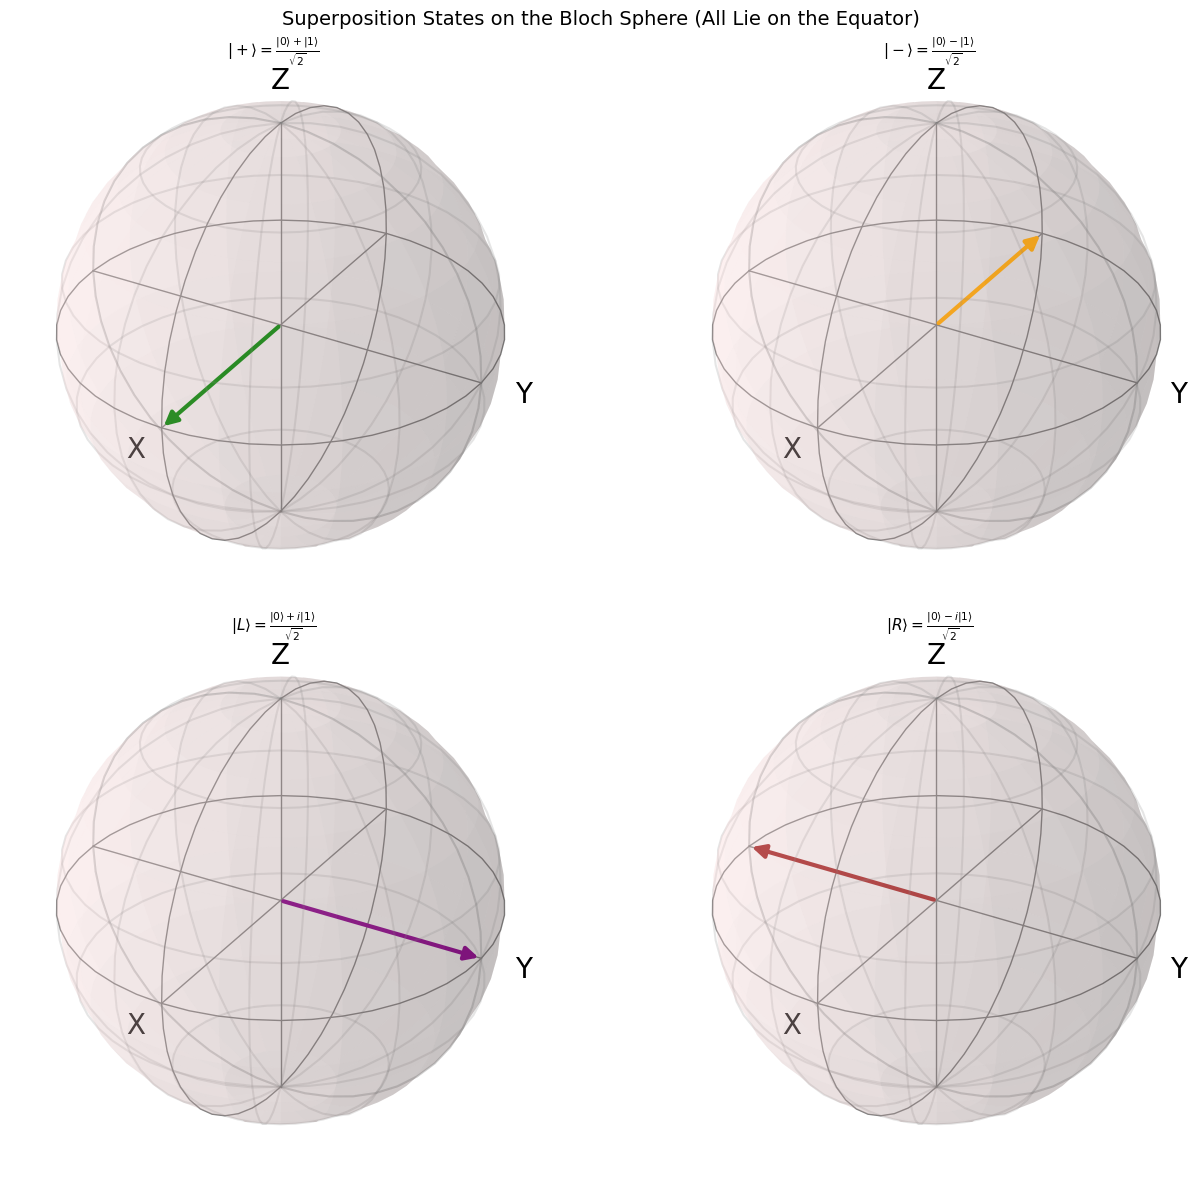


SUMMARY OF SUPERPOSITION STATES
State      Formula                             Bloch Direction     
-----------------------------------------------------------------
|+⟩        (|0⟩ + |1⟩)/√2                      +X axis (φ = 0)     
|-⟩        (|0⟩ - |1⟩)/√2                      -X axis (φ = π)     
|L⟩        (|0⟩ + i|1⟩)/√2                     +Y axis (φ = π/2)   
|R⟩        (|0⟩ - i|1⟩)/√2                     -Y axis (φ = 3π/2)  
Key Insight: All states have |α|² = |β|² = 0.5 → z = 0 (equator)
The relative phase determines the azimuthal angle φ.


In [25]:
# ============================================================================
# CELL 7b: BLOCH SPHERE VISUALIZATION OF SUPERPOSITION STATES
# Using the same working pattern as Cell 4
# ============================================================================

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# Define superposition states using QuTiP
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

psi_plus = (ket0 + ket1).unit()           # |+⟩
psi_minus = (ket0 - ket1).unit()          # |-⟩
psi_left = (ket0 + 1j * ket1).unit()      # |L⟩
psi_right = (ket0 - 1j * ket1).unit()     # |R⟩

# Create 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={'projection': '3d'})

# Plot |+⟩ (Top Left)
bloch_plus = qt.Bloch(fig=fig, axes=axes[0, 0])
bloch_plus.add_states(psi_plus)
bloch_plus.vector_color = ['green']
bloch_plus.title = r"$|+\rangle$"
bloch_plus.xlabel = ["X", ""]
bloch_plus.ylabel = ["Y", ""]
bloch_plus.zlabel = ["Z", ""]
bloch_plus.render()
axes[0, 0].set_title(r"$|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$", fontsize=11, pad=10)

# Plot |-⟩ (Top Right)
bloch_minus = qt.Bloch(fig=fig, axes=axes[0, 1])
bloch_minus.add_states(psi_minus)
bloch_minus.vector_color = ['orange']
bloch_minus.title = r"$|-\rangle$"
bloch_minus.xlabel = ["X", ""]
bloch_minus.ylabel = ["Y", ""]
bloch_minus.zlabel = ["Z", ""]
bloch_minus.render()
axes[0, 1].set_title(r"$|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$", fontsize=11, pad=10)

# Plot |L⟩ (Bottom Left)
bloch_left = qt.Bloch(fig=fig, axes=axes[1, 0])
bloch_left.add_states(psi_left)
bloch_left.vector_color = ['purple']
bloch_left.title = r"$|L\rangle$"
bloch_left.xlabel = ["X", ""]
bloch_left.ylabel = ["Y", ""]
bloch_left.zlabel = ["Z", ""]
bloch_left.render()
axes[1, 0].set_title(r"$|L\rangle = \frac{|0\rangle + i|1\rangle}{\sqrt{2}}$", fontsize=11, pad=10)

# Plot |R⟩ (Bottom Right)
bloch_right = qt.Bloch(fig=fig, axes=axes[1, 1])
bloch_right.add_states(psi_right)
bloch_right.vector_color = ['brown']
bloch_right.title = r"$|R\rangle$"
bloch_right.xlabel = ["X", ""]
bloch_right.ylabel = ["Y", ""]
bloch_right.zlabel = ["Z", ""]
bloch_right.render()
axes[1, 1].set_title(r"$|R\rangle = \frac{|0\rangle - i|1\rangle}{\sqrt{2}}$", fontsize=11, pad=10)

plt.suptitle("Superposition States on the Bloch Sphere (All Lie on the Equator)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("SUMMARY OF SUPERPOSITION STATES")
print("=" * 60)
print(f"{'State':<10} {'Formula':<35} {'Bloch Direction':<20}")
print("-" * 65)
print(f"{'|+⟩':<10} {'(|0⟩ + |1⟩)/√2':<35} {'+X axis (φ = 0)':<20}")
print(f"{'|-⟩':<10} {'(|0⟩ - |1⟩)/√2':<35} {'-X axis (φ = π)':<20}")
print(f"{'|L⟩':<10} {'(|0⟩ + i|1⟩)/√2':<35} {'+Y axis (φ = π/2)':<20}")
print(f"{'|R⟩':<10} {'(|0⟩ - i|1⟩)/√2':<35} {'-Y axis (φ = 3π/2)':<20}")
print("=" * 60)
print("Key Insight: All states have |α|² = |β|² = 0.5 → z = 0 (equator)")
print("The relative phase determines the azimuthal angle φ.")

In [28]:
# ============================================================================
# CELL 8: CREATE AND VERIFY SUPERPOSITION STATES
# ============================================================================

import numpy as np

# Define basis states (from Cell 4)
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

# Define bra and inner functions (from Cell 6)
def bra(ket):
    return np.conjugate(ket.T)

def inner(bra_vec, ket_vec):
    return np.dot(bra_vec, ket_vec)

# Create the |+⟩ state
alpha = 1 / np.sqrt(2)
beta = 1 / np.sqrt(2)
psi_plus = alpha * ket0 + beta * ket1

print("=" * 50)
print("|+⟩ STATE VERIFICATION")
print("=" * 50)
print(f"|+⟩ = {psi_plus}")
norm_plus_sq = inner(bra(psi_plus), psi_plus)
norm_plus = np.sqrt(norm_plus_sq)
print(f"Norm squared = {norm_plus_sq}")
print(f"Norm = {norm_plus}")

# Create |-⟩ state
psi_minus = alpha * ket0 - beta * ket1

print("\n" + "=" * 50)
print("|-⟩ STATE VERIFICATION")
print("=" * 50)
print(f"|-⟩ = {psi_minus}")
norm_minus = np.sqrt(inner(bra(psi_minus), psi_minus))
print(f"Norm = {norm_minus}")

# Create |R⟩ state (right-circular)
alpha_circ = 1 / np.sqrt(2)
beta_circ = 1j / np.sqrt(2)
psi_circ = alpha_circ * ket0 + beta_circ * ket1

print("\n" + "=" * 50)
print("|R⟩ STATE VERIFICATION (Right-Circular)")
print("=" * 50)
print(f"|R⟩ = {psi_circ}")
norm_circ = np.sqrt(inner(bra(psi_circ), psi_circ))
print(f"Norm = {norm_circ}")

# Create |L⟩ state (left-circular)
psi_left = alpha_circ * ket0 - beta_circ * ket1

print("\n" + "=" * 50)
print("|L⟩ STATE VERIFICATION (Left-Circular)")
print("=" * 50)
print(f"|L⟩ = {psi_left}")
norm_left = np.sqrt(inner(bra(psi_left), psi_left))
print(f"Norm = {norm_left}")

# ============================================================================
# VALIDATION CHECKS
# ============================================================================

print("\n" + "=" * 50)
print("VALIDATION CHECKS")
print("=" * 50)

# Check normalization for all states
all_normalized = True
states = [("|+⟩", norm_plus), ("|-⟩", norm_minus), ("|R⟩", norm_circ), ("|L⟩", norm_left)]

for name, norm_val in states:
    is_normalized = np.abs(norm_val - 1.0) < 1e-10
    if is_normalized:
        print(f"✅ {name} is normalized (norm = {norm_val:.10f})")
    else:
        print(f"❌ {name} is NOT normalized (norm = {norm_val:.10f})")
        all_normalized = False

# Check probability distributions
print("\n" + "-" * 50)
print("PROBABILITY DISTRIBUTIONS")
print("-" * 50)

all_equal_prob = True
prob_states = [("|+⟩", psi_plus), ("|-⟩", psi_minus), ("|R⟩", psi_circ), ("|L⟩", psi_left)]

for name, state in prob_states:
    prob_0 = np.abs(state[0])**2
    prob_1 = np.abs(state[1])**2
    is_equal = np.abs(prob_0 - 0.5) < 1e-10 and np.abs(prob_1 - 0.5) < 1e-10

    if is_equal:
        print(f"✅ {name}: P(0) = {prob_0:.3f}, P(1) = {prob_1:.3f}")
    else:
        print(f"❌ {name}: P(0) = {prob_0:.3f}, P(1) = {prob_1:.3f}")
        all_equal_prob = False

# ============================================================================
# FINAL VERIFICATION
# ============================================================================

print("\n" + "=" * 50)
print("FINAL VERIFICATION")
print("=" * 50)

if all_normalized and all_equal_prob:
    print("✅ All superposition states are normalized (norm = 1)")
    print("✅ Each has equal probability (0.5) of measuring |0⟩ or |1⟩")
else:
    print("❌ Some tests failed. Please check your calculations.")

|+⟩ STATE VERIFICATION
|+⟩ = [0.7071+0.j 0.7071+0.j]
Norm squared = (0.9999999999999998+0j)
Norm = (0.9999999999999999+0j)

|-⟩ STATE VERIFICATION
|-⟩ = [ 0.7071+0.j -0.7071+0.j]
Norm = (0.9999999999999999+0j)

|R⟩ STATE VERIFICATION (Right-Circular)
|R⟩ = [0.7071+0.j     0.    +0.7071j]
Norm = (0.9999999999999999+0j)

|L⟩ STATE VERIFICATION (Left-Circular)
|L⟩ = [0.7071+0.j     0.    -0.7071j]
Norm = (0.9999999999999999+0j)

VALIDATION CHECKS
✅ |+⟩ is normalized (norm = 1.0000000000+0.0000000000j)
✅ |-⟩ is normalized (norm = 1.0000000000+0.0000000000j)
✅ |R⟩ is normalized (norm = 1.0000000000+0.0000000000j)
✅ |L⟩ is normalized (norm = 1.0000000000+0.0000000000j)

--------------------------------------------------
PROBABILITY DISTRIBUTIONS
--------------------------------------------------
✅ |+⟩: P(0) = 0.500, P(1) = 0.500
✅ |-⟩: P(0) = 0.500, P(1) = 0.500
✅ |R⟩: P(0) = 0.500, P(1) = 0.500
✅ |L⟩: P(0) = 0.500, P(1) = 0.500

FINAL VERIFICATION
✅ All superposition states are normalized (

## 4. Outer Products and Projection Operators

The **outer product** $|\psi\rangle\langle\phi|$ produces a matrix. When $|\phi\rangle = |\psi\rangle$, it is a **projector** onto the subspace spanned by $|\psi\rangle$:

$$ P_\psi = |\psi\rangle\langle\psi| $$

Projectors satisfy two important properties:

| Property    | Mathematical condition | Meaning                                      |
|:------------|:-----------------------|:---------------------------------------------|
| **Idempotent** | $P^2 = P$              | Applying the projector twice is same as applying it once |
| **Hermitian**  | $P^\dagger = P$         | The matrix is equal to its conjugate transpose |

### Computational Basis Projectors

The projectors onto the computational basis states are:

$$ P_0 = |0\rangle\langle 0| = \begin{pmatrix} 1 & 0 \\ 0 & 0 \end{pmatrix}, \quad P_1 = |1\rangle\langle 1| = \begin{pmatrix} 0 & 0 \\ 0 & 1 \end{pmatrix} $$

These projectors form a **resolution of the identity**:

$$ P_0 + P_1 = I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} $$

### Geometric Interpretation

Applying $P_0$ to a general state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ extracts the $|0\rangle$ component:

$$ P_0|\psi\rangle = \alpha|0\rangle $$

The probability of measuring $|0\rangle$ is given by the expectation value of $P_0$:

$$ \langle\psi|P_0|\psi\rangle = |\alpha|^2 $$

### Key Insight

Projectors are the mathematical representation of **quantum measurements**. When you measure a quantum state in the computational basis, the state collapses to $|0\rangle$ with probability $\langle\psi|P_0|\psi\rangle$ and to $|1\rangle$ with probability $\langle\psi|P_1|\psi\rangle$.

In [29]:
# ============================================================================
# CELL 10: OUTER PRODUCT AND PROJECTOR IMPLEMENTATION
# ============================================================================

import numpy as np

# Define basis states (from Cell 4)
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

# Define bra function (from Cell 6)
def bra(ket):
    return np.conjugate(ket.T)

def outer(ket1, ket2):
    """
    Return the outer product |ket1⟩⟨ket2|.

    Parameters
    ----------
    ket1 : np.ndarray
        First ket (column vector)
    ket2 : np.ndarray
        Second ket (column vector)

    Returns
    -------
    np.ndarray
        Outer product matrix
    """
    return np.outer(ket1, bra(ket2))


# ============================================================================
# COMPUTATIONAL BASIS PROJECTORS
# ============================================================================

print("=" * 60)
print("COMPUTATIONAL BASIS PROJECTORS")
print("=" * 60)

# Projectors onto basis states
P0 = outer(ket0, ket0)  # |0⟩⟨0|
P1 = outer(ket1, ket1)  # |1⟩⟨1|

print("\nP0 = |0⟩⟨0| =")
print(P0)
print("\nP1 = |1⟩⟨1| =")
print(P1)

# ============================================================================
# RESOLUTION OF IDENTITY
# ============================================================================

print("\n" + "=" * 60)
print("RESOLUTION OF IDENTITY")
print("=" * 60)

identity = P0 + P1
print("\nP0 + P1 =")
print(identity)
print("\nIs this the identity matrix?", np.allclose(identity, np.eye(2)))

# ============================================================================
# PROJECTOR PROPERTIES
# ============================================================================

print("\n" + "=" * 60)
print("PROJECTOR PROPERTIES")
print("=" * 60)

# Check idempotence: P² = P
P0_squared = P0 @ P0
P1_squared = P1 @ P1

print(f"\nP0² =\n{P0_squared}")
print(f"\nP0² == P0? {np.allclose(P0_squared, P0)}")

print(f"\nP1² =\n{P1_squared}")
print(f"\nP1² == P1? {np.allclose(P1_squared, P1)}")

# Check Hermiticity: P† = P
P0_dagger = np.conjugate(P0.T)
P1_dagger = np.conjugate(P1.T)

print(f"\nP0† =\n{P0_dagger}")
print(f"P0† == P0? {np.allclose(P0_dagger, P0)}")

print(f"\nP1† =\n{P1_dagger}")
print(f"P1† == P1? {np.allclose(P1_dagger, P1)}")

# ============================================================================
# APPLYING PROJECTORS TO A STATE
# ============================================================================

print("\n" + "=" * 60)
print("APPLYING PROJECTORS TO A STATE")
print("=" * 60)

# Create |+⟩ state
alpha = 1 / np.sqrt(2)
beta = 1 / np.sqrt(2)
psi_plus = alpha * ket0 + beta * ket1

print(f"\n|+⟩ = {psi_plus}")

# Apply P0 to |+⟩
P0_psi = P0 @ psi_plus
print(f"\nP0|+⟩ = {P0_psi}")
print(f"This equals α|0⟩ = {alpha * ket0}")

# Probability of measuring |0⟩
prob_0 = np.vdot(psi_plus, P0 @ psi_plus)  # ⟨ψ|P0|ψ⟩
print(f"\nProbability of measuring |0⟩ = ⟨+|P0|+⟩ = {prob_0:.3f}")

# Apply P1 to |+⟩
P1_psi = P1 @ psi_plus
print(f"\nP1|+⟩ = {P1_psi}")
print(f"This equals β|1⟩ = {beta * ket1}")

# Probability of measuring |1⟩
prob_1 = np.vdot(psi_plus, P1 @ psi_plus)  # ⟨ψ|P1|ψ⟩
print(f"\nProbability of measuring |1⟩ = ⟨+|P1|+⟩ = {prob_1:.3f}")

# Verify probabilities sum to 1
print(f"\nP(0) + P(1) = {prob_0:.3f} + {prob_1:.3f} = {prob_0 + prob_1:.3f}")

# ============================================================================
# VALIDATION CHECKS
# ============================================================================

print("\n" + "=" * 60)
print("VALIDATION CHECKS")
print("=" * 60)

all_passed = True

# Check 1: Resolution of identity
if np.allclose(P0 + P1, np.eye(2)):
    print("✅ P0 + P1 = I (Resolution of identity)")
else:
    print("❌ P0 + P1 ≠ I")
    all_passed = False

# Check 2: Idempotence
if np.allclose(P0 @ P0, P0) and np.allclose(P1 @ P1, P1):
    print("✅ P0² = P0 and P1² = P1 (Idempotence)")
else:
    print("❌ Idempotence property failed")
    all_passed = False

# Check 3: Hermiticity
if np.allclose(np.conjugate(P0.T), P0) and np.allclose(np.conjugate(P1.T), P1):
    print("✅ P0† = P0 and P1† = P1 (Hermiticity)")
else:
    print("❌ Hermiticity property failed")
    all_passed = False

# Check 4: Probabilities sum to 1
if np.abs((prob_0 + prob_1) - 1.0) < 1e-10:
    print(f"✅ Probabilities sum to 1: {prob_0:.3f} + {prob_1:.3f} = {prob_0 + prob_1:.3f}")
else:
    print(f"❌ Probabilities sum to {prob_0 + prob_1:.3f}, not 1")
    all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("🎉 All tests passed! Projectors behave as expected.")
else:
    print("❌ Some tests failed. Please check your implementation.")
print("=" * 60)

COMPUTATIONAL BASIS PROJECTORS

P0 = |0⟩⟨0| =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

P1 = |1⟩⟨1| =
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

RESOLUTION OF IDENTITY

P0 + P1 =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Is this the identity matrix? True

PROJECTOR PROPERTIES

P0² =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

P0² == P0? True

P1² =
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

P1² == P1? True

P0† =
[[1.-0.j 0.-0.j]
 [0.-0.j 0.-0.j]]
P0† == P0? True

P1† =
[[0.-0.j 0.-0.j]
 [0.-0.j 1.-0.j]]
P1† == P1? True

APPLYING PROJECTORS TO A STATE

|+⟩ = [0.7071+0.j 0.7071+0.j]

P0|+⟩ = [0.7071+0.j 0.    +0.j]
This equals α|0⟩ = [0.7071+0.j 0.    +0.j]

Probability of measuring |0⟩ = ⟨+|P0|+⟩ = 0.500+0.000j

P1|+⟩ = [0.    +0.j 0.7071+0.j]
This equals β|1⟩ = [0.    +0.j 0.7071+0.j]

Probability of measuring |1⟩ = ⟨+|P1|+⟩ = 0.500+0.000j

P(0) + P(1) = 0.500+0.000j + 0.500+0.000j = 1.000+0.000j

VALIDATION CHECKS
✅ P0 + P1 = I (Resolution of identity)
✅ P0² = P0 and P1² = P1 (Idempotence)
✅ P0† = P0 and P1† = P1 (He

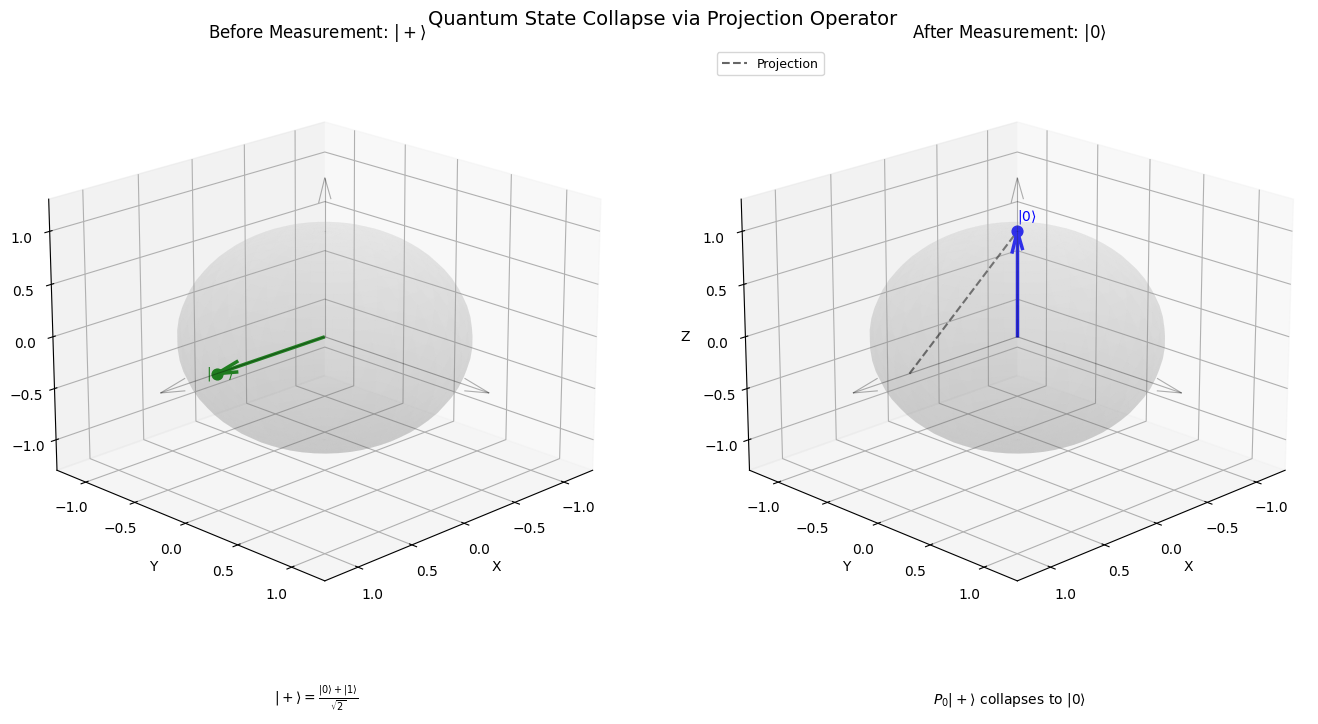

PROJECTION VISUALIZATION EXPLANATION

Left Bloch Sphere (Before Measurement):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Green vector |+⟩ lies on the EQUATOR
• This means the state is an EQUAL superposition of |0⟩ and |1⟩
• P(0) = |⟨0|+⟩|² = 0.5  and  P(1) = |⟨1|+⟩|² = 0.5

Right Bloch Sphere (After Measurement):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Blue vector |0⟩ points to the NORTH POLE
• When we measure and get outcome 0, the state COLLAPSES to |0⟩
• The projection operator P₀ = |0⟩⟨0| extracts the |0⟩ component
• The dashed line shows the "path" of collapse (conceptual)

Key Insight:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Measurement collapses the state from the equator to the north pole.
The probability of this collapse is |⟨0|+⟩|² = 0.5.
The other 50% of the time, the state would collapse to |1⟩ (south pole).

MATHEMATICAL VERIFICATION

|+⟩ = [0.7071+0.j 0

In [31]:
# ============================================================================
# CELL 11: VISUALIZING PROJECTORS USING MATPLOTLIB (No QuTiP rendering issues)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def state_to_bloch(alpha, beta):
    """Convert quantum state (α, β) to Bloch coordinates (x, y, z)."""
    x = 2 * np.real(alpha * np.conjugate(beta))
    y = 2 * np.imag(alpha * np.conjugate(beta))
    z = np.abs(alpha)**2 - np.abs(beta)**2
    return x, y, z

def draw_bloch_sphere(ax, title=""):
    """Draw an empty Bloch sphere with axes."""
    # Draw sphere
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:30j]
    x_sphere = np.cos(u) * np.sin(v)
    y_sphere = np.sin(u) * np.sin(v)
    z_sphere = np.cos(v)
    ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.15, edgecolor='none')

    # Draw coordinate axes
    ax.quiver(0, 0, 0, 1.5, 0, 0, color='black', arrow_length_ratio=0.15, alpha=0.3, linewidth=0.8)
    ax.quiver(0, 0, 0, 0, 1.5, 0, color='black', arrow_length_ratio=0.15, alpha=0.3, linewidth=0.8)
    ax.quiver(0, 0, 0, 0, 0, 1.5, color='black', arrow_length_ratio=0.15, alpha=0.3, linewidth=0.8)

    # Labels
    ax.set_xlim([-1.3, 1.3])
    ax.set_ylim([-1.3, 1.3])
    ax.set_zlim([-1.3, 1.3])
    ax.set_xlabel("X", fontsize=10)
    ax.set_ylabel("Y", fontsize=10)
    ax.set_zlabel("Z", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.view_init(elev=20, azim=45)

    return ax

def add_state_to_bloch(ax, alpha, beta, color, label, linestyle='-', show_label=True):
    """Add a state vector to an existing Bloch sphere."""
    x, y, z = state_to_bloch(alpha, beta)
    ax.quiver(0, 0, 0, x, y, z, color=color, linestyle=linestyle,
              arrow_length_ratio=0.2, linewidth=2.5)
    ax.scatter([x], [y], [z], color=color, s=60, zorder=10)
    if show_label:
        ax.text(x*1.1, y*1.1, z*1.1, label, color=color, fontsize=10, fontweight='bold')
    return ax

# ============================================================================
# CREATE THE VISUALIZATION
# ============================================================================

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': '3d'})

# ============================================================================
# LEFT PLOT: Original |+⟩ state before measurement
# ============================================================================
ax_left = draw_bloch_sphere(axes[0], r"Before Measurement: $|+\rangle$")
add_state_to_bloch(ax_left, 1/np.sqrt(2), 1/np.sqrt(2), 'green', r'$|+\rangle$', '-')

# Add annotation
axes[0].text2D(0.5, -0.1, r"$|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$",
               transform=axes[0].transAxes, ha='center', fontsize=10)

# ============================================================================
# RIGHT PLOT: After projection onto |0⟩
# ============================================================================
ax_right = draw_bloch_sphere(axes[1], r"After Measurement: $|0\rangle$")
add_state_to_bloch(ax_right, 1, 0, 'blue', r'$|0\rangle$', '-')

# Add annotation
axes[1].text2D(0.5, -0.1, r"$P_0|+\rangle$ collapses to $|0\rangle$",
               transform=axes[1].transAxes, ha='center', fontsize=10)

# ============================================================================
# ADD A DASHED ARROW SHOWING THE PROJECTION PATH
# ============================================================================
# Add a curved arrow or dotted line from |+⟩ to |0⟩
# This visually represents the collapse

# Get coordinates
x_plus, y_plus, z_plus = state_to_bloch(1/np.sqrt(2), 1/np.sqrt(2))
x_zero, y_zero, z_zero = state_to_bloch(1, 0)

# Draw a dashed line from |+⟩ to |0⟩ on the right plot to show projection
ax_right.plot([x_plus, x_zero], [y_plus, y_zero], [z_plus, z_zero],
              'k--', linewidth=1.5, alpha=0.6, label="Projection")
ax_right.legend(loc='upper left', fontsize=9)

plt.suptitle("Quantum State Collapse via Projection Operator", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# ============================================================================
# EXPLANATION TEXT
# ============================================================================

print("=" * 70)
print("PROJECTION VISUALIZATION EXPLANATION")
print("=" * 70)

print("""
Left Bloch Sphere (Before Measurement):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Green vector |+⟩ lies on the EQUATOR
• This means the state is an EQUAL superposition of |0⟩ and |1⟩
• P(0) = |⟨0|+⟩|² = 0.5  and  P(1) = |⟨1|+⟩|² = 0.5

Right Bloch Sphere (After Measurement):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Blue vector |0⟩ points to the NORTH POLE
• When we measure and get outcome 0, the state COLLAPSES to |0⟩
• The projection operator P₀ = |0⟩⟨0| extracts the |0⟩ component
• The dashed line shows the "path" of collapse (conceptual)

Key Insight:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Measurement collapses the state from the equator to the north pole.
The probability of this collapse is |⟨0|+⟩|² = 0.5.
The other 50% of the time, the state would collapse to |1⟩ (south pole).
""")

# ============================================================================
# MATHEMATICAL VERIFICATION
# ============================================================================

print("=" * 70)
print("MATHEMATICAL VERIFICATION")
print("=" * 70)

# Calculate using numpy
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
psi_plus = (1/np.sqrt(2)) * ket0 + (1/np.sqrt(2)) * ket1

# Projector P0
P0 = np.outer(ket0, np.conjugate(ket0.T))

print(f"\n|+⟩ = {psi_plus}")
print(f"\nP₀ = |0⟩⟨0| = \n{P0}")
print(f"\nP₀|+⟩ = {P0 @ psi_plus}")

# Normalize the projected state
projected_norm = P0 @ psi_plus
normalized = projected_norm / np.linalg.norm(projected_norm)
print(f"\nAfter normalization: {normalized}")
print(f"\nThis is exactly |0⟩ = {ket0}")

print("\n" + "=" * 70)
print("✅ Projection operator extracts the |0⟩ component of the state.")
print("✅ The state collapses to |0⟩ upon measurement with probability 0.5.")
print("=" * 70)

## 6. Geometric Representation of Inner and Outer Products

### Inner Product: Measuring Overlap

The inner product $\langle\phi|\psi\rangle$ quantifies how "close" two quantum states are to each other.

**Geometric Interpretation on the Bloch Sphere:**

For two states represented by Bloch vectors $\vec{a}$ and $\vec{b}$:

$$ |\langle\phi|\psi\rangle|^2 = \frac{1 + \vec{a} \cdot \vec{b}}{2} $$

| Value of $|\langle\phi|\psi\rangle|^2$ | Geometric Meaning | Example |
|:---------------------------------------|:------------------|:--------|
| $1$                                    | States are identical (same point) | `⟨ψ|ψ⟩` = 1 |
| $0$                                    | States are orthogonal (antipodal points) | `⟨0|1⟩` = 0 |
| $0.5$                                  | States are $90^\circ$ apart on the sphere | `⟨0|+⟩` = 1/$\sqrt{2}$ |

**Key Properties:**

- The inner product is a **complex number** (it carries phase information)
- The magnitude $|\langle\phi|\psi\rangle|$ is the **cosine of the angle** between the states
- The phase of $\langle\phi|\psi\rangle$ encodes relative phase information

### Outer Product: Building Operators

The outer product $|\psi\rangle\langle\phi|$ creates an operator (matrix) from two states.

**Geometric Interpretation:**

| Operation | Geometric Meaning |
|:----------|:------------------|
| $|\psi\rangle\langle\phi|$ | Maps $|\phi\rangle$ to $|\psi\rangle$, and annihilates states orthogonal to $|\phi\rangle$ |
| $|\psi\rangle\langle\psi|$ | Projector onto the direction of $|\psi\rangle$ |
| $\sum_i |e_i\rangle\langle e_i|$ | Resolution of identity (complete set of orthonormal basis) |

### Visualizing Inner Product: State Overlap

Below is a visualization showing the overlap between different quantum states.

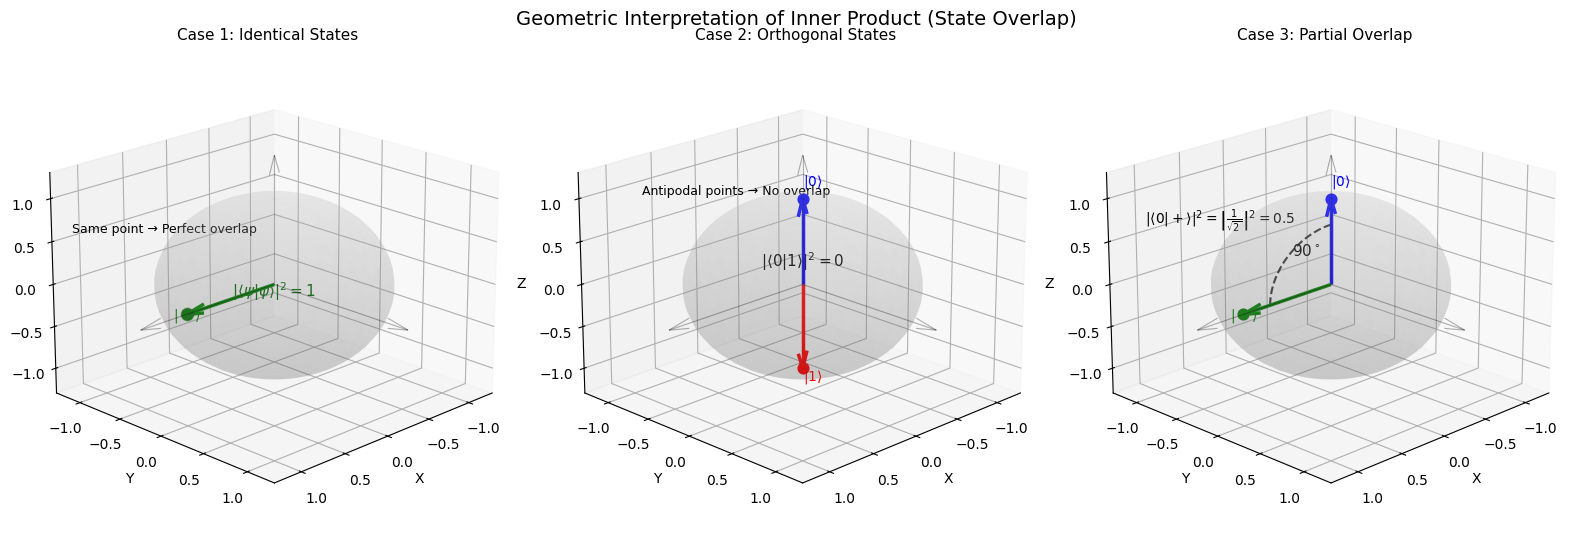

UNDERSTANDING PARTIAL OVERLAP

What does "Partial Overlap" mean?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Two quantum states have PARTIAL OVERLAP when they are neither identical nor 
completely orthogonal (opposite). This means:

• They are DIFFERENT points on the Bloch sphere
• They are NOT antipodal (not 180° apart)
• The angle between them is between 0° and 180°

Example: |0⟩ and |+⟩
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

|0⟩  = (0, 0, 1)     → North Pole
|+⟩ = (1, 0, 0)      → Equator (along X-axis)

The angle between them is 90°.

The overlap is: |⟨0|+⟩|² = |1/√2|² = 0.5

This means: If you have a qubit in state |+⟩ and you measure it in the 
computational basis (|0⟩, |1⟩), you have a 50% chance of getting |0⟩.

Geometric Formula:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

For two states with Bloch vectors a and b:

    |⟨ϕ|ψ⟩|² = (1 + a·b) / 2

• a·b = 1   → Sam

In [34]:
# ============================================================================
# CELL 14b: GEOMETRIC VISUALIZATION OF INNER PRODUCTS (Partial Overlap Explained)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def state_to_bloch(alpha, beta):
    """Convert quantum state to Bloch coordinates."""
    x = 2 * np.real(alpha * np.conjugate(beta))
    y = 2 * np.imag(alpha * np.conjugate(beta))
    z = np.abs(alpha)**2 - np.abs(beta)**2
    return x, y, z

def draw_bloch_sphere(ax, title=""):
    """Draw an empty Bloch sphere."""
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:30j]
    x_sphere = np.cos(u) * np.sin(v)
    y_sphere = np.sin(u) * np.sin(v)
    z_sphere = np.cos(v)
    ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.15, edgecolor='none')

    ax.quiver(0, 0, 0, 1.5, 0, 0, color='black', arrow_length_ratio=0.15, alpha=0.3, linewidth=0.8)
    ax.quiver(0, 0, 0, 0, 1.5, 0, color='black', arrow_length_ratio=0.15, alpha=0.3, linewidth=0.8)
    ax.quiver(0, 0, 0, 0, 0, 1.5, color='black', arrow_length_ratio=0.15, alpha=0.3, linewidth=0.8)

    ax.set_xlim([-1.3, 1.3])
    ax.set_ylim([-1.3, 1.3])
    ax.set_zlim([-1.3, 1.3])
    ax.set_xlabel("X", fontsize=10)
    ax.set_ylabel("Y", fontsize=10)
    ax.set_zlabel("Z", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.view_init(elev=20, azim=45)
    return ax

def add_vector(ax, alpha, beta, color, label, linestyle='-', show_label=True):
    """Add a state vector to Bloch sphere."""
    x, y, z = state_to_bloch(alpha, beta)
    ax.quiver(0, 0, 0, x, y, z, color=color, linestyle=linestyle,
              arrow_length_ratio=0.2, linewidth=2.5)
    ax.scatter([x], [y], [z], color=color, s=60, zorder=10)
    if show_label:
        ax.text(x*1.15, y*1.15, z*1.15, label, color=color, fontsize=10, fontweight='bold')
    return ax

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), subplot_kw={'projection': '3d'})

# ============================================================================
# PLOT 1: IDENTICAL STATES (Overlap = 1)
# ============================================================================
ax1 = draw_bloch_sphere(axes[0], r"Case 1: Identical States")
add_vector(ax1, 1/np.sqrt(2), 1/np.sqrt(2), 'green', r'$|+\rangle$')
# Add a second overlapping vector (slightly offset for visibility)
x, y, z = state_to_bloch(1/np.sqrt(2), 1/np.sqrt(2))
ax1.scatter([x], [y], [z], color='darkgreen', s=80, marker='o', alpha=0.5)
ax1.text(0.5, 0.5, 0.2, r"$|\langle\psi|\psi\rangle|^2 = 1$", fontsize=11, ha='center', color='darkgreen')
ax1.text(0.5, -0.8, 0.5, r"Same point → Perfect overlap", fontsize=9, ha='center', color='black')

# ============================================================================
# PLOT 2: ORTHOGONAL STATES (Overlap = 0)
# ============================================================================
ax2 = draw_bloch_sphere(axes[1], r"Case 2: Orthogonal States")
add_vector(ax2, 1, 0, 'blue', r'$|0\rangle$')
add_vector(ax2, 0, 1, 'red', r'$|1\rangle$')
ax2.text(0, 0, 0.2, r"$|\langle0|1\rangle|^2 = 0$", fontsize=11, ha='center', color='black')
ax2.text(0, -0.8, 0.8, r"Antipodal points → No overlap", fontsize=9, ha='center', color='black')

# ============================================================================
# PLOT 3: PARTIAL OVERLAP (Overlap = 0.5)
# ============================================================================
ax3 = draw_bloch_sphere(axes[2], r"Case 3: Partial Overlap")
add_vector(ax3, 1, 0, 'blue', r'$|0\rangle$')
add_vector(ax3, 1/np.sqrt(2), 1/np.sqrt(2), 'green', r'$|+\rangle$')

# Add angle arc to show the 90° separation
theta_arc = np.linspace(0, np.pi/2, 30)
radius = 0.7
x_arc = radius * np.sin(theta_arc)
y_arc = np.zeros_like(theta_arc)
z_arc = radius * np.cos(theta_arc)
ax3.plot(x_arc, y_arc, z_arc, 'k--', linewidth=1.5, alpha=0.8)

# Add angle label
ax3.text(0.55, 0.1, 0.55, r'$90^\circ$', fontsize=11, color='black', fontweight='bold')

# Add overlap formula
ax3.text(0.5, -0.8, 0.6, r"$|\langle0|+\rangle|^2 = \left|\frac{1}{\sqrt{2}}\right|^2 = 0.5$",
         fontsize=10, ha='center', color='black', fontweight='bold')

plt.suptitle("Geometric Interpretation of Inner Product (State Overlap)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# ============================================================================
# DETAILED EXPLANATION
# ============================================================================

print("=" * 70)
print("UNDERSTANDING PARTIAL OVERLAP")
print("=" * 70)

print("""
What does "Partial Overlap" mean?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Two quantum states have PARTIAL OVERLAP when they are neither identical nor
completely orthogonal (opposite). This means:

• They are DIFFERENT points on the Bloch sphere
• They are NOT antipodal (not 180° apart)
• The angle between them is between 0° and 180°

Example: |0⟩ and |+⟩
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

|0⟩  = (0, 0, 1)     → North Pole
|+⟩ = (1, 0, 0)      → Equator (along X-axis)

The angle between them is 90°.

The overlap is: |⟨0|+⟩|² = |1/√2|² = 0.5

This means: If you have a qubit in state |+⟩ and you measure it in the
computational basis (|0⟩, |1⟩), you have a 50% chance of getting |0⟩.

Geometric Formula:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

For two states with Bloch vectors a and b:

    |⟨ϕ|ψ⟩|² = (1 + a·b) / 2

• a·b = 1   → Same point      → |⟨ϕ|ψ⟩|² = 1
• a·b = 0   → Perpendicular    → |⟨ϕ|ψ⟩|² = 0.5
• a·b = -1  → Opposite points  → |⟨ϕ|ψ⟩|² = 0

For |0⟩ and |+⟩:
    a = (0, 0, 1),  b = (1, 0, 0)
    a·b = 0
    |⟨0|+⟩|² = (1 + 0)/2 = 0.5  ✓
""")

# ============================================================================
# CALCULATE OVERLAPS FOR DIFFERENT ANGLES
# ============================================================================

print("=" * 70)
print("OVERLAP FOR DIFFERENT ANGLES ON BLOCH SPHERE")
print("=" * 70)

print(f"\n{'Angle between states':<25} {'Dot Product (a·b)':<20} {'Overlap |⟨ϕ|ψ⟩|²':<20}")
print("-" * 70)

angles = [0, 30, 45, 60, 90, 120, 150, 180]
for angle_deg in angles:
    angle_rad = np.radians(angle_deg)
    dot_product = np.cos(angle_rad)
    overlap = (1 + dot_product) / 2
    print(f"{angle_deg}°{'':<20} {dot_product:<+20.2f} {overlap:<20.3f}")

print("\n" + "=" * 70)
print("KEY TAKEAWAYS")
print("=" * 70)
print("""
✅ Overlap = 1   → States are IDENTICAL (0° apart)
✅ Overlap = 0.5 → States are 90° apart (e.g., |0⟩ and |+⟩)
✅ Overlap = 0   → States are ORTHOGONAL (180° apart, antipodal)

The inner product |⟨ϕ|ψ⟩|² is a measure of how "close" two quantum states are.
It directly gives the probability of measuring one state as the other.
""")
print("=" * 70)

In [33]:
# ============================================================================
# CELL 14c: GEOMETRIC REPRESENTATION OF OUTER PRODUCTS
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Define states
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
psi_plus = (1/np.sqrt(2)) * ket0 + (1/np.sqrt(2)) * ket1

def bra(ket):
    return np.conjugate(ket.T)

def outer(ket1, ket2):
    return np.outer(ket1, bra(ket2))

# Create projectors
P0 = outer(ket0, ket0)
P1 = outer(ket1, ket1)
P_plus = outer(psi_plus, psi_plus)

print("=" * 70)
print("OUTER PRODUCTS AND PROJECTORS")
print("=" * 70)

print("\n1. Outer Product as a Matrix:")
print("-" * 50)
print(f"|0⟩⟨0| = \n{P0}")
print(f"\n|1⟩⟨1| = \n{P1}")

print("\n2. Geometric Interpretation of Projectors:")
print("-" * 50)
print("""
|ψ⟩⟨ψ| acts as a PROJECTOR onto the direction of |ψ⟩.

When applied to any state |φ⟩:
• The component parallel to |ψ⟩ is preserved
• The component orthogonal to |ψ⟩ is annihilated

Example: P0|ψ⟩ = α|0⟩  (extracts the |0⟩ component)
""")

print("\n3. Resolution of Identity (Completeness):")
print("-" * 50)
identity = P0 + P1
print(f"|0⟩⟨0| + |1⟩⟨1| = \n{identity}")
print(f"Is this the identity matrix? {np.allclose(identity, np.eye(2))}")

print("\n" + "=" * 70)
print("VISUALIZING PROJECTION: Before and After")
print("=" * 70)

# Apply projector P0 to |+⟩
projected = P0 @ psi_plus

print(f"\nOriginal |+⟩ state:           {psi_plus}")
print(f"After applying P0 = |0⟩⟨0|:   {projected}")
print(f"After normalization:          {projected / np.linalg.norm(projected)}")
print(f"\nThis is exactly |0⟩ = {ket0}")

print("\n" + "=" * 70)
print("GEOMETRIC SUMMARY")
print("=" * 70)
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  INNER PRODUCT ⟨φ|ψ⟩                                                        │
│  • Measures overlap between two states                                      │
│  • Output: Complex number                                                   │
│  • |⟨φ|ψ⟩|² = Probability of finding |ψ⟩ in state |φ⟩                       │
│  • Geometric meaning: Cosine of angle between Bloch vectors                 │
├─────────────────────────────────────────────────────────────────────────────┤
│  OUTER PRODUCT |ψ⟩⟨φ|                                                       │
│  • Creates an operator (matrix) from two states                             │
│  • Maps |φ⟩ → |ψ⟩                                                           │
│  • When |ψ⟩ = |φ⟩, it's a PROJECTOR onto that state                         │
│  • Projectors are idempotent (P² = P) and Hermitian (P† = P)                │
└─────────────────────────────────────────────────────────────────────────────┘
""")
print("=" * 70)

OUTER PRODUCTS AND PROJECTORS

1. Outer Product as a Matrix:
--------------------------------------------------
|0⟩⟨0| = 
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

|1⟩⟨1| = 
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

2. Geometric Interpretation of Projectors:
--------------------------------------------------

|ψ⟩⟨ψ| acts as a PROJECTOR onto the direction of |ψ⟩.

When applied to any state |φ⟩:
• The component parallel to |ψ⟩ is preserved
• The component orthogonal to |ψ⟩ is annihilated

Example: P0|ψ⟩ = α|0⟩  (extracts the |0⟩ component)


3. Resolution of Identity (Completeness):
--------------------------------------------------
|0⟩⟨0| + |1⟩⟨1| = 
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Is this the identity matrix? True

VISUALIZING PROJECTION: Before and After

Original |+⟩ state:           [0.7071+0.j 0.7071+0.j]
After applying P0 = |0⟩⟨0|:   [0.7071+0.j 0.    +0.j]
After normalization:          [1.+0.j 0.+0.j]

This is exactly |0⟩ = [1.+0.j 0.+0.j]

GEOMETRIC SUMMARY

┌────────────────────────────

## 8. Summary

### Key Concepts Covered in Day 1

| Concept              | Mathematical Expression                                | Python Implementation         | Bloch Sphere Interpretation              |
|:---------------------|:-------------------------------------------------------|:------------------------------|:-----------------------------------------|
| **Ket (state vector)** | `|ψ⟩` = $\begin{pmatrix}\alpha \\ \beta\end{pmatrix}$    | `np.array([alpha, beta])`     | Point on sphere                          |
| **Bra (dual vector)**  | `⟨ψ|` = $\begin{pmatrix}\alpha^* & \beta^*\end{pmatrix}$ | `np.conjugate(ket.T)`         | Dual point                               |
| **Inner product**    | `⟨φ|ψ⟩` = $\sum_i \phi_i^* \psi_i$     | `np.dot(bra(phi), ket(psi))`  | `|⟨φ|ψ⟩|^2` = $\frac{1 + \vec{a} \cdot \vec{b}}{2}$ |
| **Outer product**    | `|ψ⟩⟨φ|` = $\begin{pmatrix} \alpha\gamma^* & \alpha\delta^* \\ \beta\gamma^* & \beta\delta^* \end{pmatrix}$ | `np.outer(ket1, bra(ket2))`   | Projection operator                      |
| **Projector**        | $P_\psi = `|ψ⟩⟨ψ|`$                    | `np.outer(psi, bra(psi))`     | Maps any state to `|ψ⟩` direction     |
| **Norm**             | $|| `|ψ⟩` || = \sqrt{`⟨ψ|ψ⟩`}$      | `np.sqrt(inner(bra(psi), psi))` | Distance from origin                     |
| **Orthogonal states** | `⟨φ|ψ⟩` = 0                       | `inner(bra(phi), psi) == 0`   | Antipodal points on sphere               |

### Important Distinctions

| Comparison                  | Explanation                                                                            |
|:----------------------------|:---------------------------------------------------------------------------------------|
| **`|0⟩` vs. $\mathbf{0}$** | `|0⟩` is a basis state (north pole); $\mathbf{0}$ is the zero vector (origin) — only the zero vector has zero norm |
| **Inner vs. Outer product** | Inner product gives a complex number (overlap); Outer product gives a matrix (operator) |
| **Global vs. Relative phase** | Global phase ($e^{i\theta}`|ψ⟩`$) is unobservable; Relative phase (between $\alpha$ and $\beta$) determines Bloch sphere azimuth |
| **Pure vs. Mixed states**   | Pure states are points on Bloch sphere surface; Mixed states are interior points (to be covered in Phase 2) |

### Mathematical Formulas to Remember

1. **Normalization:** $\langle\psi|\psi\rangle = |\alpha|^2 + |\beta|^2 = 1$

2. **Probability of measurement:** $P(0) = |\langle 0 | \psi \rangle|^2 = |\alpha|^2$

3. **Bloch sphere coordinates:**
   - $x = 2 \text{Re}(\alpha \beta^*)$
   - $y = 2 \text{Im}(\alpha \beta^*)$
   - $z = |\alpha|^2 - |\beta|^2$

4. **State from Bloch coordinates:** $|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$

5. **Resolution of identity:** $|0\rangle\langle 0| + |1\rangle\langle 1| = I$

6. **Projector properties:** $P^2 = P$ (idempotent), $P^\dagger = P$ (Hermitian)

### Visualization Summary

| State   | Bloch Sphere Location | Coordinates $(x, y, z)$ | Overlap with `|0⟩` |
|:--------|:--------------------|:------------------------|:-------------------------|
| `|0⟩`    | North Pole            | $(0, 0, 1)$             | $1$                      |
| `|1⟩`    | South Pole            | $(0, 0, -1)$            | $0$                      |
| `|+⟩`    | Equator ($+X$)        | $(1, 0, 0)$             | $0.5$                    |
| `|-⟩`    | Equator ($-X$)        | $(-1, 0, 0)$            | $0.5$                    |
| `|L⟩`    | Equator ($+Y$)        | $(0, 1, 0)$             | $0.5$                    |
| `|R⟩`    | Equator ($-Y$)        | $(0, -1, 0)$            | $0.5$                    |

### Key Takeaways

> 1. **Dirac notation** is the language of quantum mechanics — bras, kets, inner/outer products are essential tools.
>
> 2. **The Bloch sphere** provides a geometric visualization of qubit states. Pure states live on the surface.
>
> 3. **The inner product** measures overlap between states and gives measurement probabilities.
>
> 4. **Projectors** represent quantum measurements and collapse the state upon observation.
>
> 5. **`|0⟩` is not the zero vector** — this is a common confusion to avoid.

### What's Next in Day 2?

| Topic                       | Description                                   |
|:----------------------------|:----------------------------------------------|
| **Global vs. Relative Phase** | Why only relative phase matters physically    |
| **Single-Qubit Gates**      | $X$, $Y$, $Z$, $H$ gates as rotations on Bloch sphere |
| **Gate Composition**        | Combining multiple gates                      |
| **Quantum Circuits**        | Basic circuit diagrams and execution          |
| **Visualizing Gate Operations** | Rotating states on the Bloch sphere           |

---

**Day 1 Complete!** 🎉

You have built a solid foundation in:
- Complex vector spaces and Hilbert spaces
- Dirac notation (bras, kets, inner/outer products)
- Quantum states and the Bloch sphere
- Projectors and measurement
- Positive definiteness

Proceed to Day 2 when ready.